In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = False

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants
only_clinvar = False

# selected_categories = ['missense']
# selected_categories = ['plof', 'missense', 'splicing', 'conservation', 'regulatory'] # Gene Body
selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [3]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

# olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_GENCODEv39_260218_rep0.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
# rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# 89 GTEx tissue tracks:
gtex_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_gtex_min = pl.min_horizontal(gtex_cols),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_GENCODEv39_260218_rep0.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_91304/2818384784.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_gtex_min
str,str,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,-0.004409
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,-0.013746
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,-0.003757
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.003302
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.004555,-0.004555
…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.033511,-0.017778
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.021009,-0.006965
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,-0.008397


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
    )
)

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_91304/4269321354.py:47: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_91304/4269321354.py:56: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


zoopriphylop,cadd_raw,verphylop,am_pathogenicity,gpn_score,esmscoremissense,clinpred_score,zooverphylop,id,cpt1_llr,bayes_del,priphylop,revel_score,mamphylop,polyphen,region,esm1b_llr
f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32,f32,f32,f32,f32,str,f32
0.922,3.590097,1.441,0.0,-3.37,-5.163,0.123807,0.007,"""chr2:69806485:G:A""",0.0,-0.463124,-0.189,0.112,1.518,0.478,"""ENSG00000196975""",0.0
0.984,6.16941,6.361,0.7364,-7.45,-8.921,0.988754,8.592,"""chr8:85245865:G:A""",0.488022,-0.150968,0.566,0.657,4.179,0.704,"""ENSG00000185015""",-9.649
0.128,2.099496,7.378,0.0955,-3.79,-3.917,0.438804,2.616,"""chr16:2105338:G:A""",0.111251,-0.34363,0.569,0.17,2.684,0.185,"""ENSG00000008710""",-5.263
0.333,3.755799,4.125,0.1372,-5.58,-5.359,0.974324,6.282,"""chr3:52826552:T:C""",0.33022,-0.4955,0.469,0.183,3.333,0.998,"""ENSG00000055955""",-3.782
0.999,3.429851,5.995,0.1046,-6.3,-3.734,0.193747,8.796,"""chr2:178759017:G:T""",0.090379,-0.263677,0.595,0.3,4.494,0.0,"""ENSG00000155657""",-3.468
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.997,3.887949,5.351,0.0,-8.39,-7.978,0.912852,8.661,"""chr1:174976121:C:G""",0.0,-0.388376,0.418,0.148,2.907,0.158,"""ENSG00000152061""",0.0
0.998,4.461692,8.403,0.6682,-11.78,-11.235,0.919632,6.332,"""chr4:75800628:A:G""",0.683063,0.143811,0.475,0.473,3.37,0.331,"""ENSG00000138768""",-13.044
0.003,1.50937,2.517,0.1443,-5.27,-8.245,0.333387,-1.473,"""chr11:62521585:A:C""",0.209372,-0.661452,0.463,0.078,1.04,0.564,"""ENSG00000124942""",-8.573


In [6]:
melted_anno = (
    anno

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr2:69806485:G:A""","""ENSG00000196975""","""zoopriphylop""",0.922
"""chr8:85245865:G:A""","""ENSG00000185015""","""zoopriphylop""",0.984
"""chr16:2105338:G:A""","""ENSG00000008710""","""zoopriphylop""",0.128
"""chr3:52826552:T:C""","""ENSG00000055955""","""zoopriphylop""",0.333
"""chr2:178759017:G:T""","""ENSG00000155657""","""zoopriphylop""",0.999
…,…,…,…
"""chr1:174976121:C:G""","""ENSG00000152061""","""zooverphylop""",8.661
"""chr4:75800628:A:G""","""ENSG00000138768""","""zooverphylop""",6.332
"""chr11:62521585:A:C""","""ENSG00000124942""","""zooverphylop""",-1.473


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Small APPV file has no 'region' column — region is added via id_region join in the computation cell
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(-pl.col('mean_pheno_value')) # Descending for olink
    )
    .select(['id', 'phenotype', 'mean_pheno_value', 'n_individuals'])
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → olink_whitelist (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(
        olink_whitelist[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan

    .join(
        anno_config_df,
        on='annotation'
    )
    .join(
        olink_whitelist,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64
"""ENSG00000134827""","""ENSG00000134827_olink""","""bayes_del""",41,0.081547,"""missense""","""#feb72d""","""BayesDel""",1,0.102696,0.102696,1.0,0.081547,0.794064
"""ENSG00000205186""","""ENSG00000205186_olink""","""polyphen""",17,0.16718,"""missense""","""#feb72d""","""PolyPhen2""",1,0.064857,0.064857,1.0,0.16718,2.57766
"""ENSG00000158516""","""ENSG00000158516_olink""","""polyphen""",55,0.367936,"""missense""","""#feb72d""","""PolyPhen2""",1,0.065404,0.065404,1.0,0.367936,5.625561
"""ENSG00000175535""","""ENSG00000175535_olink""","""revel_score""",34,0.488349,"""missense""","""#feb72d""","""REVEL""",1,0.066741,0.066741,1.0,0.488349,7.317131
"""ENSG00000247596""","""ENSG00000247596_olink""","""zooverphylop""",42,0.039551,"""conservation""","""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.065783,0.065783,1.0,0.039551,0.601237
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000174136""","""ENSG00000174136_olink""","""gpn_score""",55,-0.183015,"""conservation""","""#942C80""","""GPN-MSA""",-1,0.038162,0.038162,1.0,0.183015,4.795791
"""ENSG00000137101""","""ENSG00000137101_olink""","""zooverphylop""",26,-0.20106,"""conservation""","""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.056567,0.056567,1.0,-0.20106,-3.554341
"""ENSG00000091129""","""ENSG00000091129_olink""","""cpt1_llr""",116,0.099842,"""missense""","""#feb72d""","""CPT-1""",1,0.01861,0.01861,1.0,0.099842,5.36508


In [9]:
(
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['annotation'])
    .agg(n_regions = pl.len())
    .sort('n_regions', descending=True)
)

annotation,n_regions
str,u64
"""gpn_score""",1076
"""mamphylop""",1076
"""bayes_del""",1076
"""zoopriphylop""",1076
"""priphylop""",1076
…,…
"""revel_score""",1059
"""esm1b_llr""",1054
"""polyphen""",1045


In [10]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    # .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_genes, on=['region'], how='inner')
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64,u64
"""ENSG00000172009""","""ENSG00000172009_olink""","""am_pathogenicity""",118,0.679784,"""missense""","""#feb72d""","""AlphaMissense""",1,0.046802,0.046802,1.0,0.679784,14.524767,15
"""ENSG00000172009""","""ENSG00000172009_olink""","""esm1b_llr""",118,-0.670322,"""missense""","""#feb72d""","""ESM1b""",-1,0.046802,0.046802,1.0,0.670322,14.322611,15
"""ENSG00000172009""","""ENSG00000172009_olink""","""polyphen""",118,0.669588,"""missense""","""#feb72d""","""PolyPhen2""",1,0.046802,0.046802,1.0,0.669588,14.306926,15
"""ENSG00000172009""","""ENSG00000172009_olink""","""clinpred_score""",118,0.656446,"""missense""","""#feb72d""","""ClinPred""",1,0.046802,0.046802,1.0,0.656446,14.026113,15
"""ENSG00000138798""","""ENSG00000138798_olink""","""esmscoremissense""",120,-0.645906,"""missense""","""#feb72d""","""ESM1v""",-1,0.070097,0.070097,1.0,0.645906,9.214426,15
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000080031""","""ENSG00000080031_olink""","""revel_score""",136,-0.219009,"""missense""","""#feb72d""","""REVEL""",1,0.059453,0.059453,1.0,-0.219009,-3.683762,15
"""ENSG00000196411""","""ENSG00000196411_olink""","""cadd_raw""",128,-0.230859,"""genetic_diversity""","""chocolate""","""CADD Raw""",1,0.073627,0.073627,1.0,-0.230859,-3.135535,15
"""ENSG00000106665""","""ENSG00000106665_olink""","""zoopriphylop""",129,-0.247618,"""conservation""","""#942C80""","""Zoonomia Primate PhyloP""",1,0.01938,0.01938,1.0,-0.247618,-12.777077,15


In [11]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 5
Inconsistent (region, phenotype) pairs: 0


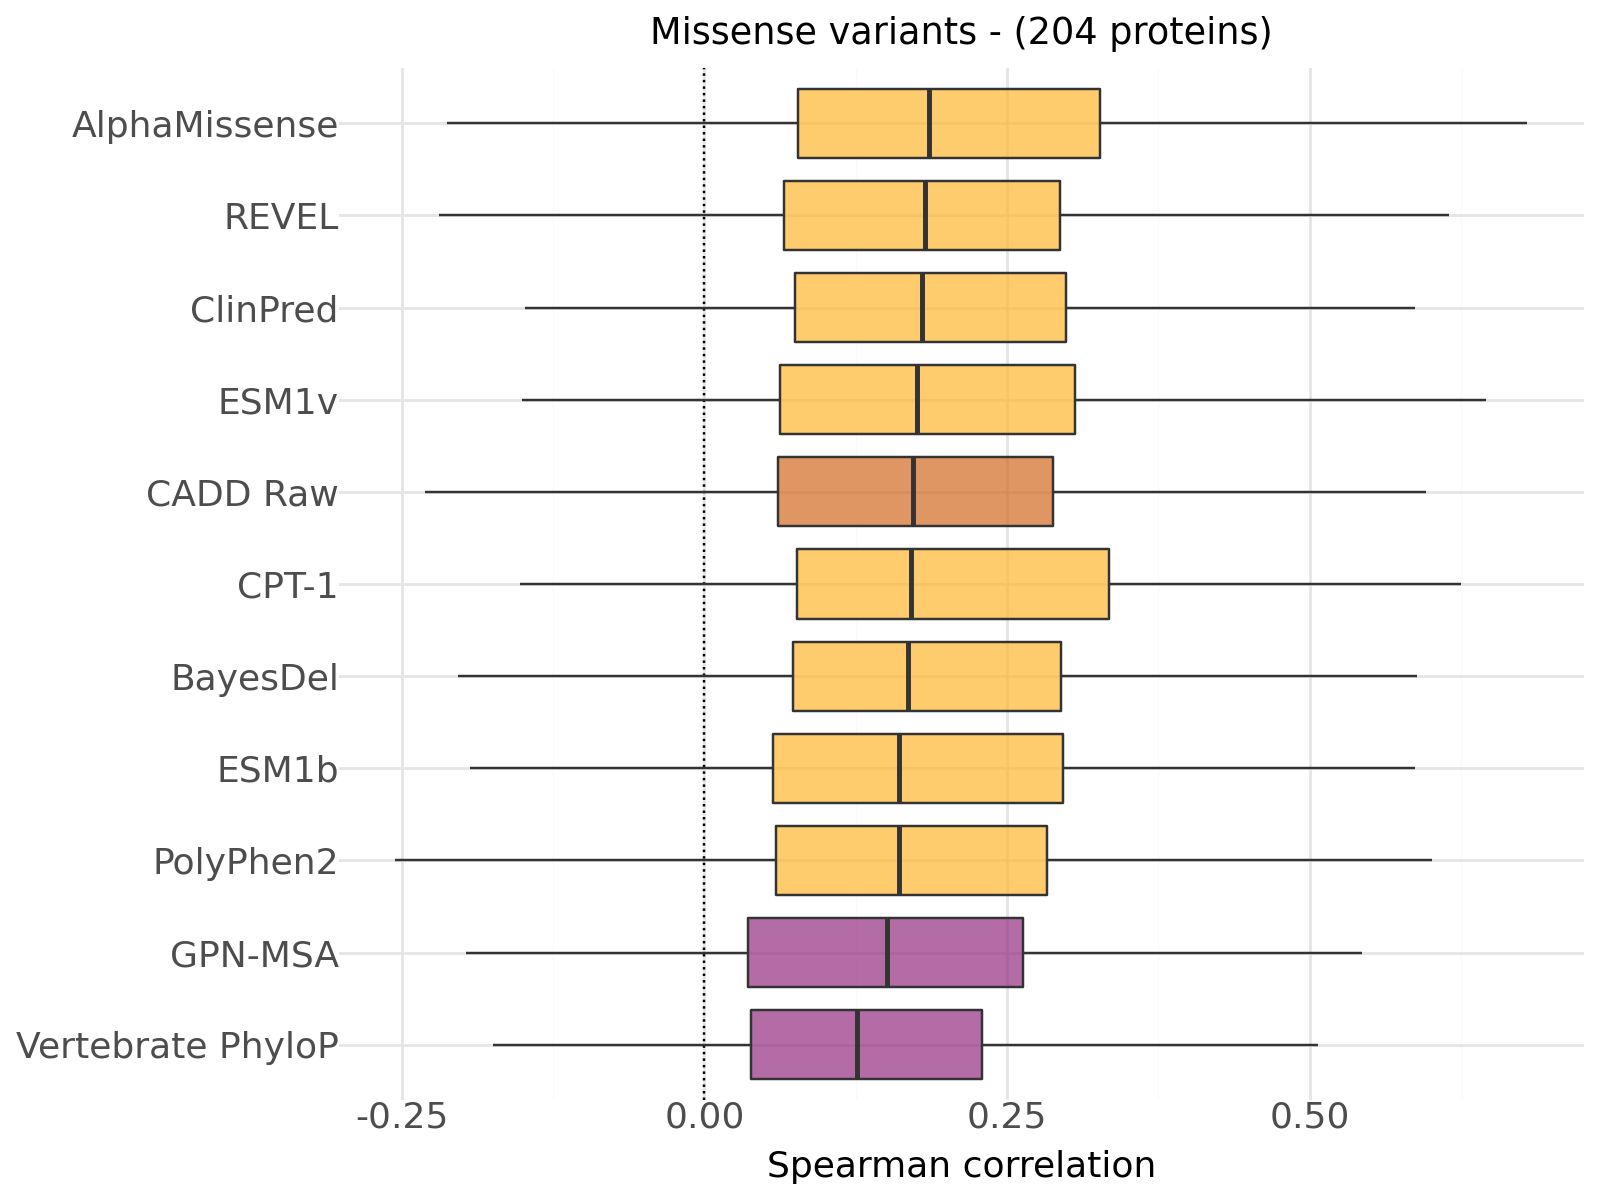

In [20]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

# Calculate medians and join back
exclude_annos = ['promoterai_over', 'abexp_min', 'zooverphylop', 'zoopriphylop', 'priphylop', 'mamphylop', 'abexp_max']
plot_corr_pl = (
    filt_corr_df
    .drop_nans()
    .filter(~pl.col('annotation').is_in(exclude_annos))
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    plot_corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
plot_corr_pl = plot_corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(plot_corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(plot_corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    # + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{plot_title} variants - ({plot_corr_pl[['region', 'phenotype']].unique().shape[0]} proteins)",
        # title=f"{plot_corr_pl[['region', 'phenotype']].unique().shape[0]} Olink - {vc['x_label']} variants"
    )
    + coord_flip()
    + theme(
        figure_size=(8, plot_corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

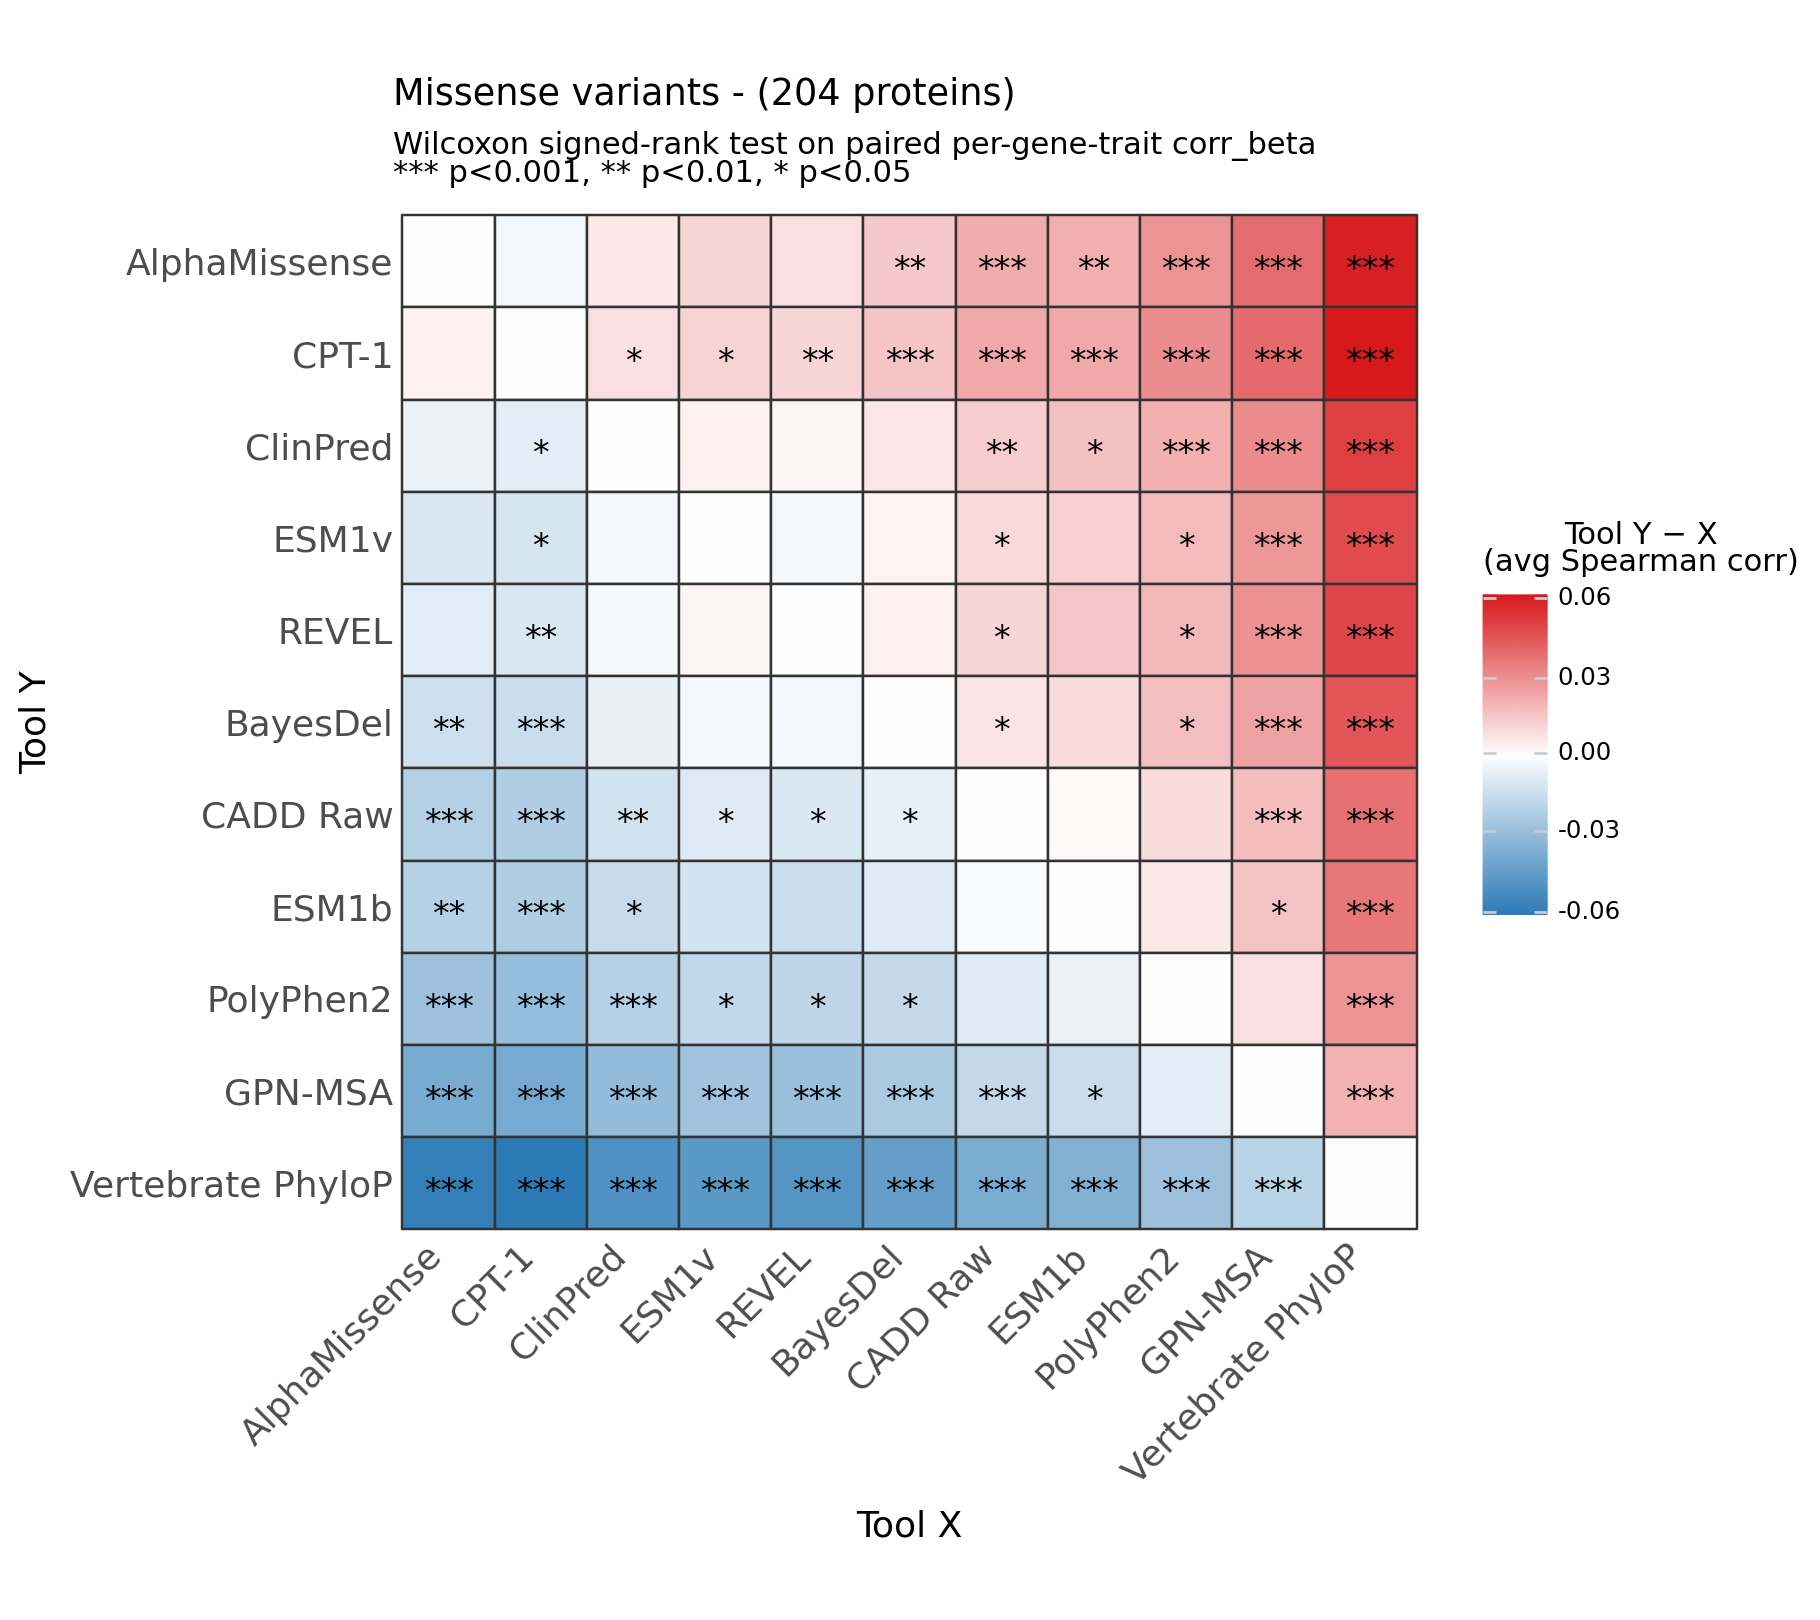

In [21]:
import pandas as pd
import itertools
import numpy as np
from scipy import stats

# --- 1. Determine annotation set and ordering ---
plot_annotations = plot_corr_pl.select("annotation").unique().to_series().to_list()

# Filter tools
plot_annotations = [a for a in plot_annotations if a not in exclude_annos]

# Build annotation -> label mapping
anno_to_label = dict(
    plot_corr_pl.select(["annotation", "label"]).unique().iter_rows()
)

# Order tools by median corr_beta (best first)
tool_medians = {}
tool_means = {}
for ann in plot_annotations:
    vals = plot_corr_pl.filter(pl.col("annotation") == ann)["corr_beta"].to_numpy()
    tool_medians[ann] = float(np.nanmedian(vals))
    tool_means[ann] = float(np.nanmean(vals))

# ordered_tools  = sorted(tool_medians.keys(), key=lambda x: tool_medians[x], reverse=True)
ordered_tools  = sorted(tool_means.keys(), key=lambda x: tool_means[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

# --- 2. Pairwise Wilcoxon signed-rank test on paired (region, phenotype) corr_beta ---
heatmap_data = []

for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
    label_x = anno_to_label.get(ann_x, ann_x)
    label_y = anno_to_label.get(ann_y, ann_y)

    if ann_x == ann_y:
        heatmap_data.append({
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': 0.0,
            'sig': ''
        })
        continue

    # Inner join on (region, phenotype) to get paired values
    df_x = plot_corr_pl.filter(pl.col("annotation") == ann_x).select(["region", "phenotype", "corr_beta"])
    df_y = plot_corr_pl.filter(pl.col("annotation") == ann_y).select(["region", "phenotype", "corr_beta"])

    paired = df_x.join(df_y, on=["region", "phenotype"], suffix="_y")
    c_x = paired["corr_beta"].to_numpy()
    c_y = paired["corr_beta_y"].to_numpy()

    mean_diff = float(c_y.mean() - c_x.mean())

    if len(c_x) >= 10 and not np.allclose(c_x, c_y):
        _, p_val = stats.wilcoxon(c_x, c_y, alternative='two-sided')
    else:
        p_val = 1.0

    if   p_val < 0.001: sig = '***'
    elif p_val < 0.01:  sig = '**'
    elif p_val < 0.05:  sig = '*'
    else:               sig = ''

    heatmap_data.append({
        'Tool_X': label_x,
        'Tool_Y': label_y,
        'mean_diff': mean_diff,
        'sig': sig
    })

df_heat = pd.DataFrame(heatmap_data)

# Lock in categorical order so best tools appear top/right
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels,       ordered=True)
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_tools = len(ordered_tools)

# --- 3. Plot ---
(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"{plot_title} variants - ({plot_corr_pl[['region', 'phenotype']].unique().shape[0]} proteins)",
        subtitle="Wilcoxon signed-rank test on paired per-gene-trait corr_beta\n*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y \u2212 X\n(avg Spearman corr)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_tools * 0.6 + 2.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_title=element_text(size=13),
        axis_text=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [14]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_91304/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""clinpred_score""","""zoopriphylop""",203,1496.0,4.1510e-26
"""cadd_raw""","""zoopriphylop""",204,1584.0,7.9268e-26
"""cpt1_llr""","""zoopriphylop""",195,1451.0,9.6184e-25
"""am_pathogenicity""","""zoopriphylop""",198,1569.0,1.0901e-24
"""clinpred_score""","""priphylop""",203,1788.0,1.6049e-24
…,…,…,…,…
"""esmscoremissense""","""polyphen""",200,8241.0,0.027294
"""clinpred_score""","""esm1b_llr""",198,8172.0,0.037609
"""cpt1_llr""","""clinpred_score""",194,7831.0,0.037788


# Stratify by LOEUF score

In [15]:
gnom = (
    pl.read_csv(
        "/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv", 
        null_values=["NA"],
        separator='\t'
    )
    .filter(
        pl.col('transcript_type')=='protein_coding',
        pl.col('canonical')==True
        # pl.col('mane_select')==True
    )
    .select(['gene_id', 'lof.oe_ci.upper'])
    .rename({'gene_id': 'region', 'lof.oe_ci.upper': 'loeuf'})
    .drop_nulls()
)

gnom

region,loeuf
str,f64
"""ENSG00000121410""",1.34
"""ENSG00000148584""",0.825
"""ENSG00000175899""",0.765
"""ENSG00000166535""",0.953
"""ENSG00000184389""",1.529
…,…
"""ENSG00000288914""",1.87
"""ENSG00000289027""",0.885
"""ENSG00000289258""",0.982


In [16]:
set(correlation_df['region'].unique()) - set(gnom['region'].unique())

set()

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 20'. Pick better value with 'binwidth'.


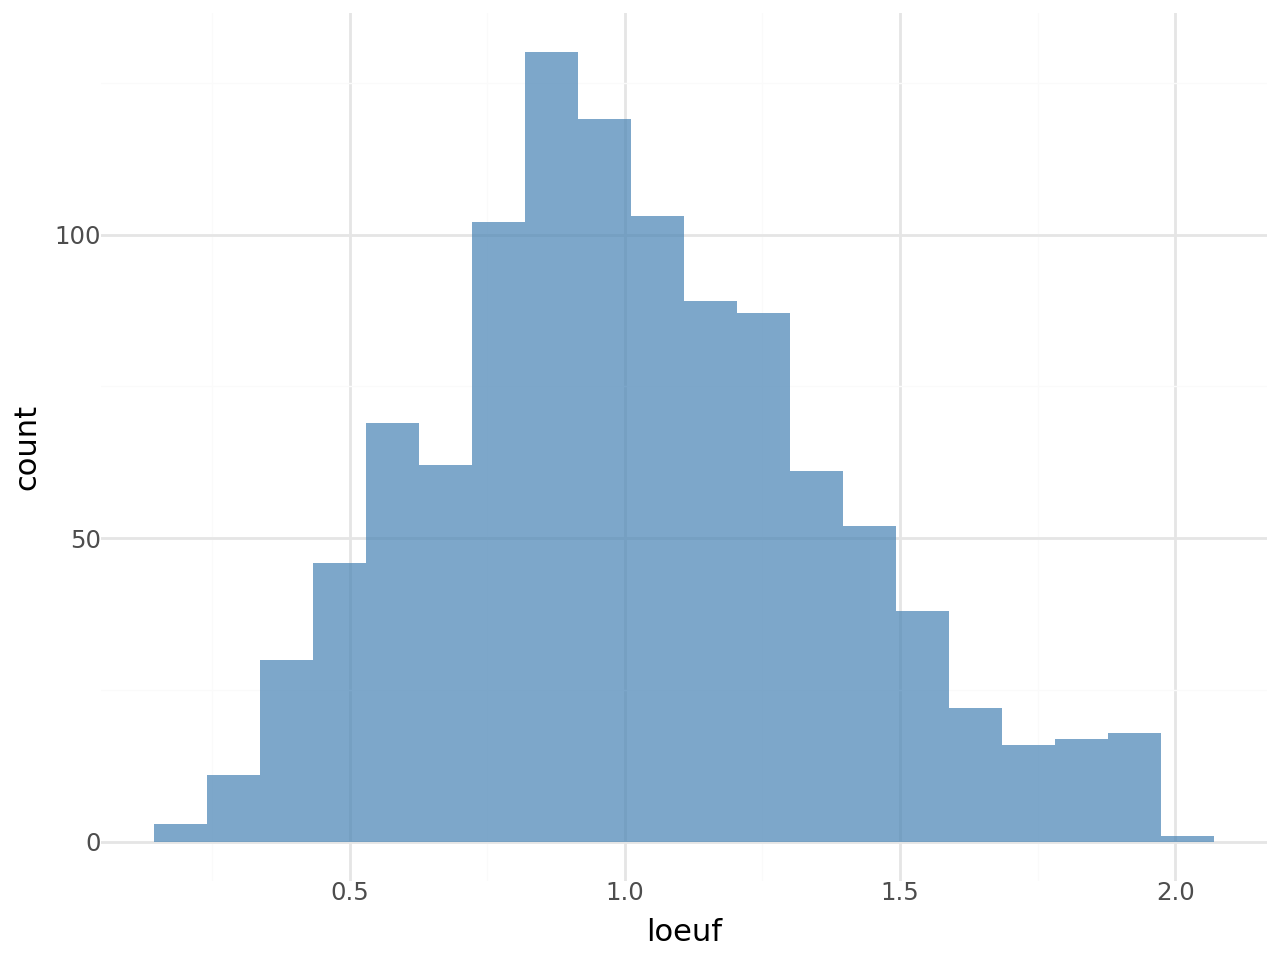

In [17]:
tmp = gnom.join(correlation_df.select(['region']).unique(), on='region', how='inner').with_columns(subset=pl.lit('ukbbgym_pheno'))

(
    ggplot(tmp, aes(x='loeuf'))
    + geom_histogram(position='identity', fill='steelblue', alpha=0.7)
    + theme_minimal()
)

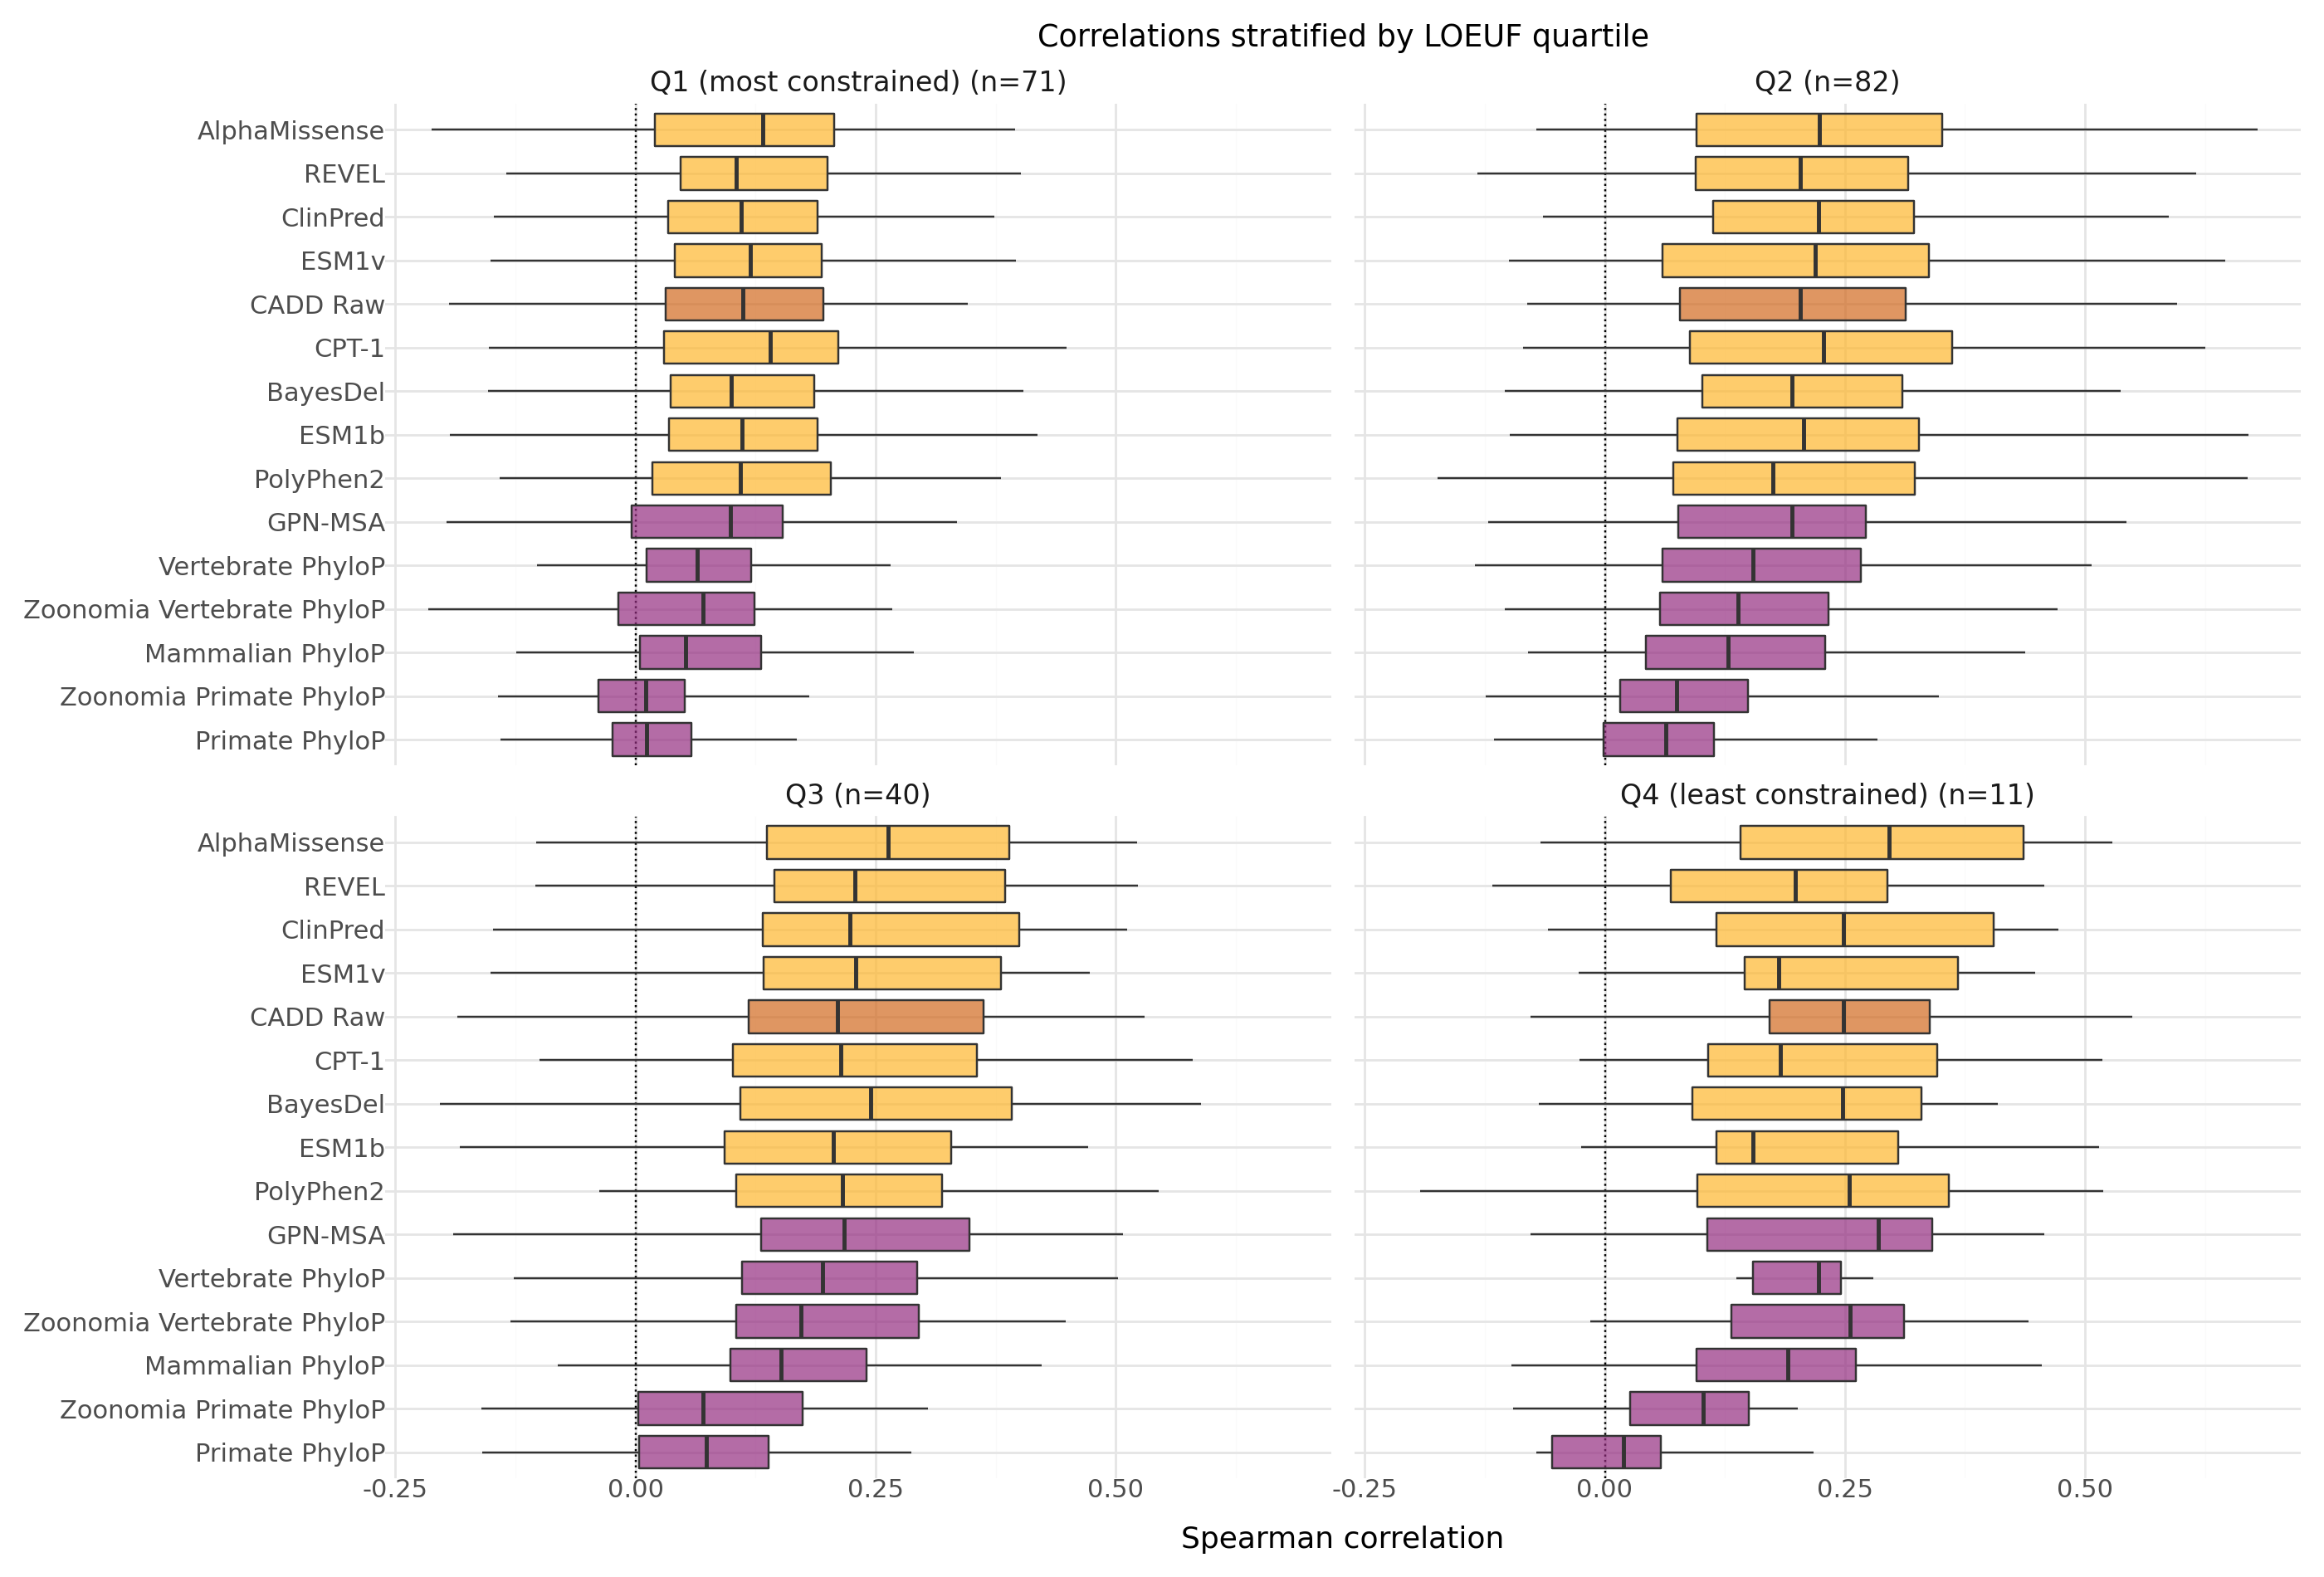

In [18]:
# Create 4 LOEUF bins from the full gnomAD constraint table
loeuf_bins = gnom.with_columns(
    loeuf_bin = pl.col('loeuf').qcut(4, labels=['Q1 (most constrained)', 'Q2', 'Q3', 'Q4 (least constrained)'])
)

# Join LOEUF bins to filt_corr_df
corr_loeuf = (
    filt_corr_df
    .join(loeuf_bins, on='region', how='inner')
    .drop_nans()
)

# Add n= counts to the bin labels
bin_counts = (
    corr_loeuf
    .select(['region', 'phenotype', 'loeuf_bin'])
    .unique(subset=['region', 'phenotype'])
    .group_by('loeuf_bin')
    .len()
)
bin_label_map = {
    row[0]: f"{row[0]} (n={row[1]})" for row in bin_counts.iter_rows()
}
corr_loeuf = corr_loeuf.with_columns(
    pl.col('loeuf_bin').cast(pl.Utf8).replace(bin_label_map).alias('loeuf_bin')
)

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Order annotations by overall median
corr_loeuf_pl = corr_loeuf.with_columns(
    median_corr_beta = pl.col(plotting_col).median().over("annotation")
)

ordered_labels = (
    corr_loeuf_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

corr_loeuf_pl = corr_loeuf_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

color_dict = dict(corr_loeuf_pl.select("annotation", "color").unique().iter_rows())

(
    ggplot(corr_loeuf_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + facet_wrap("~loeuf_bin", ncol=2)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Correlations stratified by LOEUF quartile"
    )
    + coord_flip()
    + theme(
        figure_size=(14, corr_loeuf_pl['annotation'].n_unique()/2 + 2),
        legend_position="none",
        axis_text=element_text(size=11),
        axis_title=element_text(size=13),
        strip_text=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)